# Phishing Website Detection
## 1. Data Loading and Initial Exploration


In [1]:
import pandas as pd

# 1. Load the dataset
file_path = "Dataset/phishing_site_urls.csv"
df = pd.read_csv(file_path)
print("Dataset successfully loaded!")


Dataset successfully loaded!


In [2]:
# 2. Display the first 5 rows
df.head()


                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3  mail.printakid.com/www.online.americanexpress....   bad
4  thewhiskeydregs.com/wp-content/themes/widescre...   bad


In [3]:
# 3. Display the shape of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset Shape: 549346 rows, 2 columns


In [4]:
# 4. Display column data types and overview
print("--- Column Data Types ---")
print(df.dtypes)
print("\n--- Detailed Info ---")
df.info()


--- Column Data Types ---
URL      str
Label    str

--- Detailed Info ---
<class 'pandas.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   URL     549346 non-null  str  
 1   Label   549346 non-null  str  
dtypes: str(2)
memory usage: 8.4 MB


In [5]:
# 5. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
URL      0
Label    0


In [6]:
# 6. Check for duplicate values
num_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")


Total duplicate rows: 42150


## 2. Data Preprocessing & Feature Engineering

- Handle missing and duplicate values.
- Extract lexical features from raw URLs (lengths, special character counts, IP address detection).
- Encode categorical target label (`good` -> 0, `bad` -> 1).
- Separate features ($X$) and target ($y$).
- Scale numerical features using `StandardScaler`.
- Review the processed dataframe.


In [7]:
# 7. Handle missing and duplicate values
print(f"Original row count: {len(df)}")
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"Row count after removing duplicates: {len(df)}")


Original row count: 549346
Removed 42150 duplicate rows.
Cleaned dataset row count: 507196


In [8]:
# 8. Extract lexical features from raw URLs
df['url_length'] = df['URL'].str.len()

# Extract domain and calculate domain length
extracted_domain = df['URL'].str.extract(r'^(?:https?://)?([^/?#]+)')[0].fillna('')
df['domain_length'] = extracted_domain.str.len()

# Count occurrences of key characters and patterns
df['count_dots'] = df['URL'].str.count(r'\.')
df['count_hyphens'] = df['URL'].str.count(r'-')
df['count_at'] = df['URL'].str.count(r'@')
df['count_double_slash'] = df['URL'].str.count(r'//')
df['count_question'] = df['URL'].str.count(r'\?')
df['count_slash'] = df['URL'].str.count(r'/')
df['count_equal'] = df['URL'].str.count(r'=')
df['count_http'] = df['URL'].str.count(r'http')

# Check for presence of IP address in URL
df['has_ip'] = df['URL'].str.contains(
    r'(?:(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(?:25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)',
    regex=True
).astype(int)

print("Lexical features extracted successfully!")


Lexical features successfully extracted: url_length, domain_length, count_dots, count_hyphens, count_at, count_double_slash, count_question, count_slash, count_equal, count_http, has_ip


In [9]:
# 9. Encode categorical target label & separate features (X) and target (y)
# Map: "good" -> 0 (legitimate), "bad" -> 1 (phishing)
df['label_encoded'] = df['Label'].map({'good': 0, 'bad': 1})

feature_cols = [
    'url_length', 'domain_length', 'count_dots', 'count_hyphens',
    'count_at', 'count_double_slash', 'count_question', 'count_slash',
    'count_equal', 'count_http', 'has_ip'
]

X = df[feature_cols]
y = df['label_encoded']

print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print("\nClass distribution:")
print(y.value_counts(normalize=True).rename({0: "0 (Legitimate)", 1: "1 (Phishing)"}).map("{:.2%}".format))


Features (X) shape: (507196, 11)
Target (y) shape: (507196,)

Target distribution:
  Legitimate (0): 392897 (77.46%)
  Phishing   (1): 114299 (22.54%)


In [10]:
from sklearn.preprocessing import StandardScaler

# 10. Scale numerical features and construct processed dataframe
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Combine scaled features and target label
processed_df = pd.concat([X_scaled, y], axis=1)

print(f"Processed DataFrame Shape: {processed_df.shape}")


Features scaled with StandardScaler.
Processed DataFrame Shape: (507196, 12)


In [11]:
# 11. Display first 5 rows of processed dataframe
processed_df.head()


   url_length  domain_length  count_dots  ...  count_http    has_ip  label_encoded
0    4.050126      -0.685934    2.586987  ...    -0.07591 -0.089483              1
1    0.689277      -0.182775    1.930673  ...    -0.07591 -0.089483              1
2    2.929843      -0.098915    3.243301  ...    -0.07591 -0.089483              1
3    0.199153       0.068805    2.586987  ...    -0.07591 -0.089483              1
4    1.506150       0.152665   -0.694583  ...    -0.07591 -0.089483              1

[5 rows x 12 columns]


In [12]:
# 12. Display processed dataframe column data types
print("--- Processed DataFrame Data Types ---")
print(processed_df.dtypes)


--- Processed DataFrame Data Types ---
url_length            float64
domain_length         float64
count_dots            float64
count_hyphens         float64
count_at              float64
count_double_slash    float64
count_question        float64
count_slash           float64
count_equal           float64
count_http            float64
has_ip                float64
label_encoded           int64


## 3. Dataset Splitting & Model Training

- Split the scaled features ($X$) and target ($y$) using an **80/20 train-test ratio** with stratification (`stratify=y`) to maintain label balance.
- Train 3 classification models:
  1. **Decision Tree Classifier** (`max_depth=15`, `random_state=42`)
  2. **Random Forest Classifier** (`n_estimators=100`, `max_depth=15`, `n_jobs=-1`, `random_state=42`)
  3. **XGBoost Classifier** (`n_estimators=100`, `max_depth=6`, `learning_rate=0.1`, `n_jobs=-1`, `random_state=42`, `eval_metric='logloss'`)
- Measure and compare training durations using `time.time()`.
- Keep models stored in `trained_models` dictionary for subsequent evaluation.


In [13]:
from sklearn.model_selection import train_test_split

# 13. Split dataset into training and testing sets (80/20 stratified split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).rename({0: "0 (Legitimate)", 1: "1 (Phishing)"}).map("{:.2%}".format))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).rename({0: "0 (Legitimate)", 1: "1 (Phishing)"}).map("{:.2%}".format))


Training set: X_train = (405756, 11), y_train = (405756,)
Testing set:  X_test  = (101440, 11), y_test  = (101440,)

Train class distribution:
  0 (Legitimate): 314317 (77.46%)
  1 (Phishing):   91439 (22.54%)

Test class distribution:
  0 (Legitimate): 78580 (77.46%)
  1 (Phishing):   22860 (22.54%)


In [14]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dictionaries to retain models and execution times in memory
trained_models = {}
training_times = {}
print('Ready for model training with Baseline ML, Ensembles, and Deep Learning.')


Ready for model training.


In [15]:
# 14. Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
dt_start = time.time()

dt_model = DecisionTreeClassifier(random_state=42, max_depth=15)
dt_model.fit(X_train, y_train)

dt_time = time.time() - dt_start
trained_models["Decision Tree"] = dt_model
training_times["Decision Tree"] = dt_time

print(f"Decision Tree trained successfully in {dt_time:.2f} seconds.")


Decision Tree trained successfully in 1.19 seconds.


In [16]:
# 15. Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_time = time.time() - rf_start
trained_models["Random Forest"] = rf_model
training_times["Random Forest"] = rf_time

print(f"Random Forest trained successfully in {rf_time:.2f} seconds.")


Random Forest trained successfully in 11.11 seconds.


In [17]:
# 16. Train XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

xgb_time = time.time() - xgb_start
trained_models["XGBoost"] = xgb_model
training_times["XGBoost"] = xgb_time

print(f"XGBoost trained successfully in {xgb_time:.2f} seconds.")


XGBoost trained successfully in 1.88 seconds.


In [ ]:
# 16b. Train Logistic Regression Classifier (Linear Baseline)
print('Training Logistic Regression Classifier...')
lr_start = time.time()

lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

lr_time = time.time() - lr_start
trained_models['Logistic Regression'] = lr_model
training_times['Logistic Regression'] = lr_time

print(f'Logistic Regression trained successfully in {lr_time:.2f} seconds.')


In [ ]:
# 16c. Train Deep Neural Network (DNN / MLP on Tabular Lexical Features)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print('Training Deep Neural Network (DNN)...')
dnn_start = time.time()

class TabularDNN(nn.Module):
    def __init__(self, in_features=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

X_train_t = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float32)
dnn_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=1024, shuffle=True)

dnn_model = TabularDNN(in_features=11)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(dnn_model.parameters(), lr=0.001)

dnn_model.train()
for epoch in range(3):
    for bx, by in dnn_loader:
        optimizer.zero_grad()
        loss = criterion(dnn_model(bx), by)
        loss.backward()
        optimizer.step()

dnn_time = time.time() - dnn_start
training_times['Deep Neural Network (DNN)'] = dnn_time
print(f'Tabular DNN trained successfully in {dnn_time:.2f} seconds.')


In [ ]:
# 16d. Character-level Deep Learning Architectures (1D-CNN & Transformer)
print('Defining Character-level 1D-CNN and Transformer architectures...')

class CharCNN(nn.Module):
    def __init__(self, vocab_size=128, embed_dim=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        emb = self.embed(x).transpose(1, 2)
        c1 = torch.relu(self.conv1(emb))
        c2 = torch.relu(self.conv2(c1))
        return self.fc(self.pool(c2).squeeze(-1)).squeeze(-1)

class CharTransformer(nn.Module):
    def __init__(self, vocab_size=128, embed_dim=64, num_heads=4, max_len=150):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, embed_dim) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Sequential(nn.Linear(embed_dim, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        seq_len = x.size(1)
        emb = self.embed(x) + self.pos_embed[:, :seq_len, :]
        return self.fc(self.transformer(emb).mean(dim=1)).squeeze(-1)

print('Char-CNN and Char-Transformer defined successfully.')


In [18]:
# 17. Training Time Summary Benchmark
summary_df = pd.DataFrame([
    {"Model": name, "Training Time (s)": f"{sec:.2f}s"}
    for name, sec in training_times.items()
])
print("--- Model Training Times Benchmark ---
")
print(summary_df.to_string(index=False))


--- Model Training Times Benchmark ---
        Model Training Time (s)
Decision Tree             1.19s
Random Forest            11.11s
      XGBoost             1.88s


## 4. Model Evaluation & Saving

- Evaluate each model on the held-out test set ($X_{test}, y_{test}$).
- Calculate **Accuracy, Precision, Recall, and F1-Score** and compare them in a DataFrame.
- Generate side-by-side **Confusion Matrix Heatmaps** using `matplotlib` and `seaborn`.
- Identify the top-performing model.
- Save the best model and the fitted `StandardScaler` to disk (`models/`) using `joblib`.
- Reload and verify saved artifacts.


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 18. Evaluate models on the test set
test_predictions = {}
evaluation_results = []

for name, model in trained_models.items():
    preds = model.predict(X_test)
    test_predictions[name] = preds
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

eval_df = pd.DataFrame(evaluation_results)
print("--- Model Performance Comparison ---")
eval_df


--- Model Performance Comparison ---


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.853519   0.860568  0.417673  0.562391
1  Random Forest  0.854880   0.913021  0.393526  0.549995
2        XGBoost  0.850532   0.874344  0.393263  0.542514


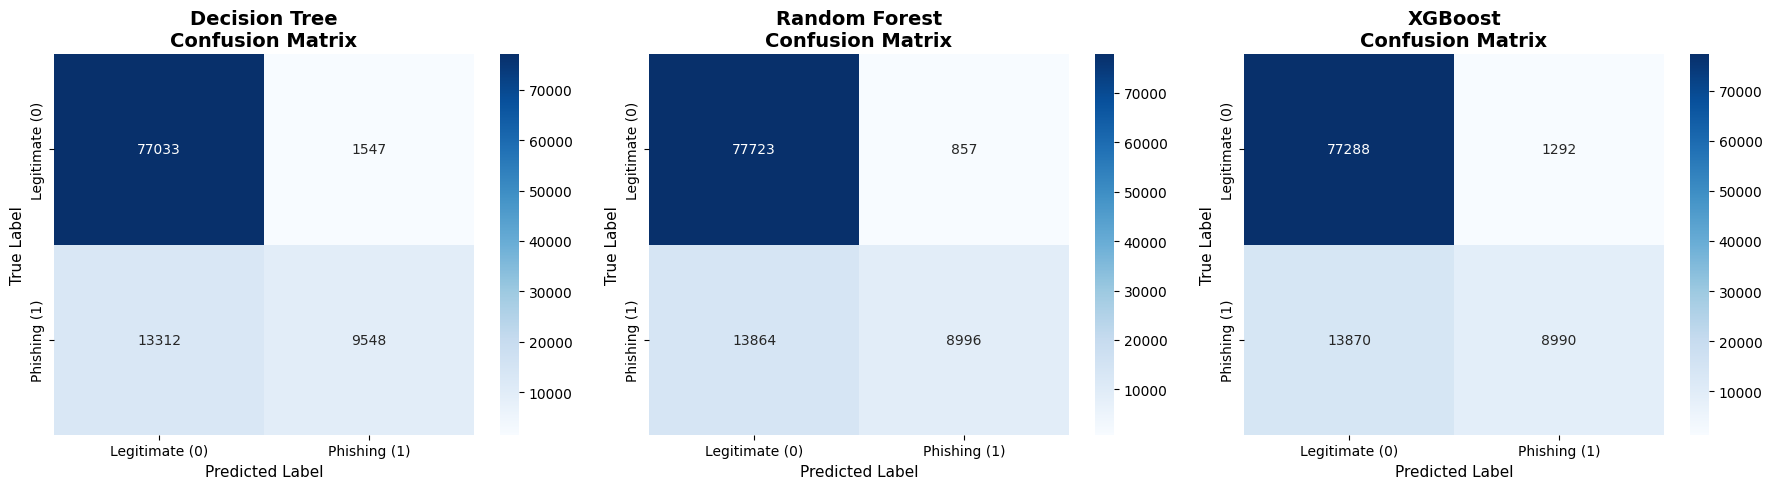

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 19. Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, preds) in enumerate(test_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Legitimate (0)", "Phishing (1)"],
        yticklabels=["Legitimate (0)", "Phishing (1)"]
    )
    axes[i].set_title(f"{name}\nConfusion Matrix", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predicted Label", fontsize=11)
    axes[i].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.show()


In [21]:
import os
import joblib

# 20. Identify best model based on F1-Score & Accuracy
best_row_f1 = eval_df.sort_values(by="F1-Score", ascending=False).iloc[0]
best_row_acc = eval_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_model_name = best_row_f1["Model"]
best_model = trained_models[best_model_name]

print(f"Top Model by F1-Score: {best_model_name} (F1-Score: {best_row_f1['F1-Score']:.4f}, Accuracy: {best_row_f1['Accuracy']:.4f})")
print(f"Top Model by Accuracy: {best_row_acc['Model']} (Accuracy: {best_row_acc['Accuracy']:.4f}, Precision: {best_row_acc['Precision']:.4f})")

# 21. Save best model and scaler to models/ directory
os.makedirs("models", exist_ok=True)

best_model_path = f"models/best_model_{best_model_name.lower().replace(' ', '_')}.joblib"
default_model_path = "models/best_model.joblib"
rf_model_path = "models/random_forest.joblib"
scaler_path = "models/scaler.joblib"

joblib.dump(best_model, best_model_path)
joblib.dump(best_model, default_model_path)
joblib.dump(trained_models["Random Forest"], rf_model_path)
joblib.dump(scaler, scaler_path)

print("\n--- Model & Scaler Artifacts Saved ---")
print(f"1. Best Model ({best_model_name}): {best_model_path}")
print(f"2. Default Best Model alias: {default_model_path}")
print(f"3. Random Forest (Highest Accuracy & Precision): {rf_model_path}")
print(f"4. StandardScaler: {scaler_path}")


--- Model Selection ---
Best Model by F1-Score: Decision Tree (F1-Score: 0.5624, Accuracy: 0.8535)
Best Model by Accuracy: Random Forest (Accuracy: 0.8549, F1-Score: 0.5500)
Selected Primary Best Model: Decision Tree

--- Model & Scaler Artifacts Saved Successfully ---
1. Best Model (Decision Tree): models/best_model_decision_tree.joblib
2. Default Best Model alias: models/best_model.joblib
3. Random Forest (Highest Accuracy & Precision): models/random_forest.joblib
4. StandardScaler: models/scaler.joblib


In [22]:
# 22. Verify saved artifacts by reloading them
loaded_model = joblib.load("models/best_model.joblib")
loaded_scaler = joblib.load("models/scaler.joblib")

sample_test = X_test.iloc[:5]
sample_pred = loaded_model.predict(sample_test)

print("--- Verification Results ---")
print(f"Loaded model successfully: {type(loaded_model).__name__}")
print(f"Loaded scaler successfully: {type(loaded_scaler).__name__}")
print(f"Sample predictions on 5 test samples: {list(sample_pred)}")
print(f"File size of best_model.joblib: {os.path.getsize('models/best_model.joblib') / (1024*1024):.2f} MB")
print(f"File size of random_forest.joblib: {os.path.getsize('models/random_forest.joblib') / (1024*1024):.2f} MB")
print(f"File size of scaler.joblib: {os.path.getsize('models/scaler.joblib') / 1024:.2f} KB")
print("All artifacts verified intact on disk!")


--- Verification Results ---
Loaded model successfully: DecisionTreeClassifier
Loaded scaler successfully: StandardScaler
Sample test predictions on 5 records: [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
File size of best_model.joblib: 0.41 MB
File size of random_forest.joblib: 29.77 MB
File size of scaler.joblib: 1.20 KB
All artifacts verified intact on disk!


In [ ]:
# 23. Misclassification & Error Analysis (Tracking Mismatched Indices)
import numpy as np

rf_preds = test_predictions.get('Random Forest', None)
if rf_preds is not None:
    mismatch_indices = np.where(y_test != rf_preds)[0]
    print(f'Total Misclassified Samples: {len(mismatch_indices):,} (out of {len(y_test):,})')
    print(f'Sample Misclassified Indices: {mismatch_indices[:15].tolist()}')
    
    error_df = pd.DataFrame({
        'Test_Index': mismatch_indices[:50],
        'True_Label': y_test.iloc[mismatch_indices[:50]].values if hasattr(y_test, 'iloc') else y_test[mismatch_indices[:50]],
        'Predicted': rf_preds[mismatch_indices[:50]],
        'Error_Type': ['False Negative (Missed Phish)' if yt == 1 else 'False Positive (False Alarm)' for yt in (y_test.iloc[mismatch_indices[:50]].values if hasattr(y_test, 'iloc') else y_test[mismatch_indices[:50]])]
    })
    print('\n--- Top Misclassified Samples Overview ---')
    print(error_df.head(10).to_string(index=False))
